### **Universidade Estadual de Londrina**

**Curso:** Ciência de Dados e Inteligência Artificial

**Disciplina:** 2COP019 - Aprendizado de Máquina Supervisionado  

**Docente:** Bruno Squizato Faical  

**Alunos:** Herik Daurizio Ricardo, Julia Yokoyama Massaki, Sofia Gutschow Casal

## **Classificação de Sentimentos e Análise Comparativa:** **TF-IDF** vs **BERT**

Este notebook implementa uma solução para triagem de avaliações de produtos do Mercado Livre em PT/BR. O fluxo de implementação foi organizado em três etapas principais:

**1. Dados e baseline TF-IDF:** carregamento do dados Json, extração, limpeza e tratamento, definição do esquema binário, balanceamento, divisão estrita em treino/validação/teste e treino do método TF-IDF;

**2. Fine-tuning com BERTimbau:** preparação textual adequada para Transformers, tokenização, treinamento e avaliação usando a mesma divisão do baseline;

**3. Análise comparativa:** comparação das métricas no mesmo conjunto de teste e investigação qualitativa de erros e suas características.


## **Etapa 0** — Preparação do ambiente

Nesta etapa são importadas as bibliotecas necessárias para processamento textual, treinamento dos modelos, avaliação e visualização. Também são definidos utilitários para garantir reprodutibilidade dos experimentos. Todas as bibliotecas requeridas estão no arquivo `requirements.txt`.

In [1]:
import json
import re
import random
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)
set_seed(SEMENTE)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 160)

# **Etapa 1** — Carga dos dados

Os dados são lidos a partir dos arquivos `reviews_mercadolivre_com_br_1.json` e `reviews_mercadolivre_com_br_2.json`.

Ambos arquivos são processados em conjunto. Após a extração, o pipeline cria um identificador único por exemplo, audita a qualidade dos dados, remove registros inválidos, descarta o rating 3, balanceia a tarefa binária e só então realiza a divisão estrita em treino, validação e teste.


In [2]:
# Função para localizar o arquivo JSON com base em uma lista de prioridades
def localizar_arquivo(prioridades):
    for nome in prioridades:
        caminho = Path(nome)
        if caminho.exists():
            return caminho
    return None

base_dir = Path("dataset")

def localizar_arquivo(nome):
    caminho = base_dir / nome
    return caminho if caminho.exists() else None

nomes_json = [
    "reviews_mercadolivre_com_br_1.json",
    "reviews_mercadolivre_com_br_2.json",
]

caminhos_existentes = []
arquivos_nao_encontrados = []

for nome_json in nomes_json:
    caminho = localizar_arquivo(nome_json)
    if caminho is not None:
        caminhos_existentes.append(caminho)
    else:
        arquivos_nao_encontrados.append(nome_json)

if not caminhos_existentes:
    raise FileNotFoundError(
        'Não foi possível localizar nenhum dos arquivos esperados: '
        + ', '.join(nomes_json)
    )

print('Arquivos JSON localizados para processamento combinado:')
for caminho in caminhos_existentes:
    print(f'- {caminho}')

if arquivos_nao_encontrados:
    print('Arquivos não encontrados:')
    for nome_json in arquivos_nao_encontrados:
        print(f'- {nome_json}')

caminhos_existentes

Arquivos JSON localizados para processamento combinado:
- dataset\reviews_mercadolivre_com_br_1.json
- dataset\reviews_mercadolivre_com_br_2.json


[WindowsPath('dataset/reviews_mercadolivre_com_br_1.json'),
 WindowsPath('dataset/reviews_mercadolivre_com_br_2.json')]

In [3]:
def carregar_json(caminho):
    with open(caminho, 'r', encoding='utf-8') as arquivo:
        dados = json.load(arquivo)
    return dados

# Função para combinar os dados em uma única estrutura
def combinar_datasets_json(caminhos):
    dados_combinados = []

    for caminho in caminhos:
        dados = carregar_json(caminho)
        if isinstance(dados, list):
            dados_combinados.extend(dados)
        else:
            dados_combinados.append(dados)

    return dados_combinados

# Função para mostrar a estrutura dos dados
def amostra_estrutura(objeto, profundidade=0, max_itens=3):
    if profundidade > 2:
        return '...'
    if isinstance(objeto, dict):
        return {chave: amostra_estrutura(valor, profundidade + 1, max_itens) for chave, valor in list(objeto.items())[:max_itens]}
    if isinstance(objeto, list):
        return [amostra_estrutura(item, profundidade + 1, max_itens) for item in objeto[:max_itens]]
    return type(objeto).__name__

for caminho in caminhos_existentes:
    dados = carregar_json(caminho)
    quantidade_registros = len(dados) if isinstance(dados, list) else 1
    print(f'Arquivo: {caminho}')
    print(f'Tipo raiz: {type(dados).__name__}')
    print(f'Quantidade de registros: {quantidade_registros}')
    print(amostra_estrutura(dados))
    print('-' * 100)

dados_combinados = combinar_datasets_json(caminhos_existentes)
print(f'Total de registros após combinar os arquivos: {len(dados_combinados)}')


Arquivo: dataset\reviews_mercadolivre_com_br_1.json
Tipo raiz: list
Quantidade de registros: 103476
[{'date': 'str', 'rating': 'int', 'content': 'str'}, {'date': 'str', 'rating': 'int', 'content': 'str'}, {'date': 'str', 'rating': 'int', 'content': 'str'}]
----------------------------------------------------------------------------------------------------
Arquivo: dataset\reviews_mercadolivre_com_br_2.json
Tipo raiz: list
Quantidade de registros: 103476
[{'date': 'str', 'rating': 'int', 'content': 'str'}, {'date': 'str', 'rating': 'int', 'content': 'str'}, {'date': 'str', 'rating': 'int', 'content': 'str'}]
----------------------------------------------------------------------------------------------------
Total de registros após combinar os arquivos: 206952


In [4]:
# Função para padronizar os registros em um DataFrame
def padronizar_registros(registros, nome_arquivo):
    linhas = []
    for indice, registro in enumerate(registros):
        linhas.append({
            'arquivo_origem': nome_arquivo,
            'indice_origem': indice,
            'data': registro.get('date'),
            'texto_bruto': registro.get('content'),
            'rating': registro.get('rating'),
            'product_url': registro.get('product_url')
        })
    return pd.DataFrame(linhas)

quadros = []
for caminho in caminhos_existentes:
    dados = carregar_json(caminho)
    quadro = padronizar_registros(dados, caminho.name)
    quadros.append(quadro)
    print(f'{caminho.name}: {len(quadro):,} registros extraídos')

dados_brutos = pd.concat(quadros, ignore_index=True)
dados_brutos['id_unico'] = (
    dados_brutos['arquivo_origem'].astype(str)
    + '::'
    + dados_brutos['indice_origem'].astype(str)
) # Constrói um ID único combinando o nome do arquivo e o índice do registro

print(f'Total extraído após padronização: {len(dados_brutos):,}')
print(f'IDs únicos duplicados: {dados_brutos["id_unico"].duplicated().sum():,}')
display(dados_brutos.head())


reviews_mercadolivre_com_br_1.json: 103,476 registros extraídos
reviews_mercadolivre_com_br_2.json: 103,476 registros extraídos
Total extraído após padronização: 206,952
IDs únicos duplicados: 0


,arquivo_origem,indice_origem,data,texto_bruto,rating,product_url,id_unico
0,reviews_mercadolivre_com_br_1.json,0,09 set. 2023,Top.,5,https://produto.mercadolivre.com.br/MLB-3149572356-shampoo-prevent-cetoconazol-anticaspa-e-coceira-100ml-10und-_JM,reviews_mercadolivre_com_br_1.json::0
1,reviews_mercadolivre_com_br_1.json,1,19 ago. 2024,"Produto bom, cumpre o que promete.",5,https://produto.mercadolivre.com.br/MLB-3149572356-shampoo-prevent-cetoconazol-anticaspa-e-coceira-100ml-10und-_JM,reviews_mercadolivre_com_br_1.json::1
2,reviews_mercadolivre_com_br_1.json,2,15 fev. 2025,Ótima qualidade.,5,https://produto.mercadolivre.com.br/MLB-3149572356-shampoo-prevent-cetoconazol-anticaspa-e-coceira-100ml-10und-_JM,reviews_mercadolivre_com_br_1.json::2
3,reviews_mercadolivre_com_br_1.json,3,11 fev. 2025,Bom.,4,https://produto.mercadolivre.com.br/MLB-3149572356-shampoo-prevent-cetoconazol-anticaspa-e-coceira-100ml-10und-_JM,reviews_mercadolivre_com_br_1.json::3
4,reviews_mercadolivre_com_br_1.json,4,10 jan. 2025,Atendeu minhas expectativas.,5,https://produto.mercadolivre.com.br/MLB-3149572356-shampoo-prevent-cetoconazol-anticaspa-e-coceira-100ml-10und-_JM,reviews_mercadolivre_com_br_1.json::4


## Etapa 1.1 — Tratamento dos dados e definição de abordagem binária

- Padronização dos ratings, remoção de textos vazios e ações de boa prática;
- O rating 3 é descartado para evitar introdução de ruído e ambiguidade;
- definição da abordagem binária: ratings 1–2 = negativo, 4–5 = positivo.


In [5]:
# Função para converter ratings para inteiros, tratando casos inválidos
def converter_rating(valor):
    try:
        return int(float(valor))
    except Exception:
        return np.nan

dados = dados_brutos.copy()
dados['rating_original'] = dados['rating']
dados['rating'] = dados['rating'].apply(converter_rating)
dados['texto_bruto'] = dados['texto_bruto'].astype(str).str.strip()

auditoria_inicial = {
    'registros_extraidos': len(dados),
    'ratings_invalidos': int(dados['rating'].isna().sum()),
    'textos_vazios': int((dados['texto_bruto'].str.len() == 0).sum()),
    'ids_duplicados': int(dados['id_unico'].duplicated().sum())
}

print('Auditoria inicial:')
for chave, valor in auditoria_inicial.items():
    print(f'- {chave}: {valor:,}')

# Limpeza básica: remove registros com ratings inválidos ou textos vazios
dados = dados.dropna(subset=['rating']).copy()
dados = dados[dados['texto_bruto'].str.len() > 0].copy()

distribuicao_original = dados['rating'].value_counts(dropna=False).sort_index()
print('Distribuição original por rating (após a limpeza):')
print(distribuicao_original)

dados = dados[dados['rating'] != 3].copy()

dados['rotulo'] = np.select(
    [
        dados['rating'].isin([1, 2]),
        dados['rating'].isin([4, 5])
    ],
    [0, 1],
    default=np.nan
)

# Cria um novo DataFrame para modelagem, mantendo apenas os registros com rótulos válidos
dados_modelagem = dados.dropna(subset=['rotulo']).copy()
dados_modelagem['rotulo'] = dados_modelagem['rotulo'].astype(int)
mapa_rotulos = {0: 'negativo', 1: 'positivo'}
dados_modelagem['classe'] = dados_modelagem['rotulo'].map(mapa_rotulos)

distribuicao_sem_neutro = dados_modelagem['rating'].value_counts(dropna=False).sort_index()
distribuicao_binaria = dados_modelagem['classe'].value_counts().sort_index()

# Relatório do tratamento inicial dos dados
print('Distribuição após excluir rating 3:')
print(distribuicao_sem_neutro)
print('Distribuição binária por sentimento:')
print(distribuicao_binaria)
print('Tabela cruzada rating x classe:')
print(pd.crosstab(dados_modelagem['rating'], dados_modelagem['classe']))

print('Exemplos:')
display(dados_modelagem[['id_unico', 'rating', 'classe', 'texto_bruto']].sample(min(5, len(dados_modelagem)), random_state=SEMENTE))

Auditoria inicial:
- registros_extraidos: 206,952
- ratings_invalidos: 0
- textos_vazios: 4,167
- ids_duplicados: 0
Distribuição original por rating (após a limpeza):
rating
1      7196
2      2777
3      5690
4     12571
5    174551
Name: count, dtype: int64
Distribuição após excluir rating 3:
rating
1      7196
2      2777
4     12571
5    174551
Name: count, dtype: int64
Distribuição binária por sentimento:
classe
negativo      9973
positivo    187122
Name: count, dtype: int64
Tabela cruzada rating x classe:
classe  negativo  positivo
rating                    
1           7196         0
2           2777         0
4              0     12571
5              0    174551
Exemplos:


,id_unico,rating,classe,texto_bruto
148966,reviews_mercadolivre_com_br_2.json::45490,5,positivo,Recomendo amei.
181547,reviews_mercadolivre_com_br_2.json::78071,5,positivo,Bom.
204292,reviews_mercadolivre_com_br_2.json::100816,5,positivo,Adorei!meu cabelo ficou muito macio e brilhante o cheiro é maravilhoso.
195996,reviews_mercadolivre_com_br_2.json::92520,2,negativo,Muito caro sem efeito.
10358,reviews_mercadolivre_com_br_1.json::10358,5,positivo,Ótimo.


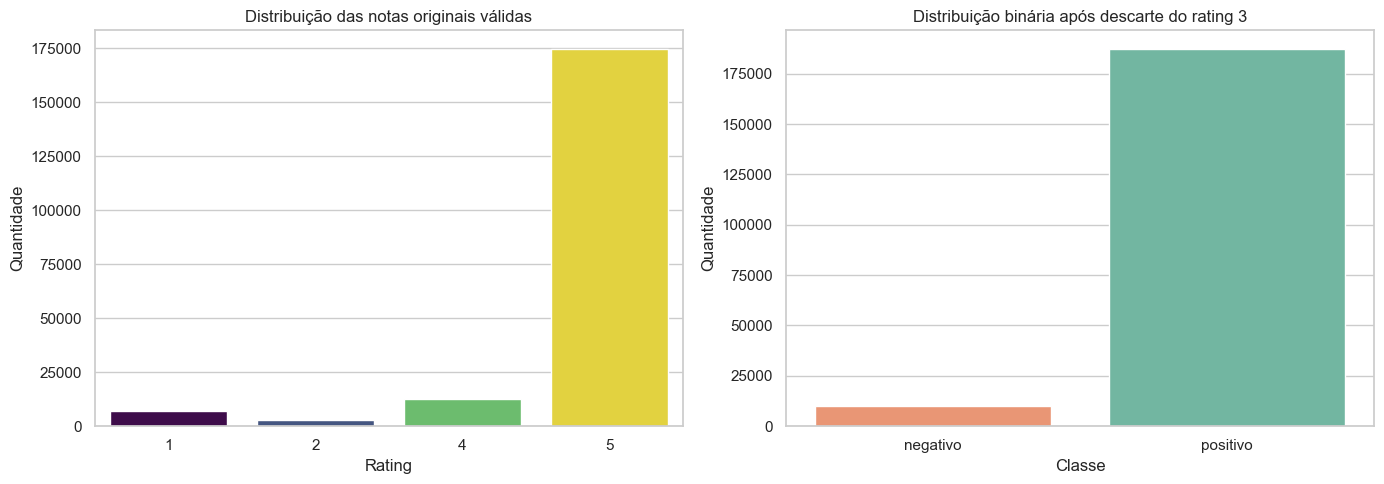

,etapa,quantidade
0,Extração padronizada,206952
1,Após limpeza básica,197095
2,Após remoção do rating 3,197095
3,Negativos (antes balanceamento),9973
4,Positivos (antes balanceamento),187122


In [6]:
# Gráficos de distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=dados_modelagem,
    x='rating',
    hue='rating',
    order=sorted(dados_modelagem['rating'].dropna().unique()),
    ax=axes[0],
    palette='viridis',
    legend=False
)
axes[0].set_title('Distribuição das notas originais válidas')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Quantidade')

sns.countplot(
    data=dados_modelagem,
    x='classe',
    hue='classe',
    order=['negativo', 'positivo'],
    ax=axes[1],
    palette='Set2',
    legend=False
)
axes[1].set_title('Distribuição binária após descarte do rating 3')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

# Tabela de resumo do tratamento
auditoria_resumo = pd.DataFrame([
    {'etapa': 'Extração padronizada', 'quantidade': len(dados_brutos)},
    {'etapa': 'Após limpeza básica', 'quantidade': len(dados)},
    {'etapa': 'Após remoção do rating 3', 'quantidade': len(dados_modelagem)},
    {'etapa': 'Negativos (antes balanceamento)', 'quantidade': int((dados_modelagem['rotulo'] == 0).sum())},
    {'etapa': 'Positivos (antes balanceamento)', 'quantidade': int((dados_modelagem['rotulo'] == 1).sum())}
])

auditoria_resumo


- O rating 5 foi o mais frequente entre as notas originais válidas.
- Após o descarte do rating 3, a base binária ficou exatamente balanceada.
- A proporção dos ratings dentro de cada classe foi mantida.

In [7]:
# Seleciona apenas os dados positivos e negativos
df_positivo = dados_modelagem[dados_modelagem['rotulo'] == 1].copy()
df_negativo = dados_modelagem[dados_modelagem['rotulo'] == 0].copy()

# Determina a quantidade da classe minoritária para balanceamento
qtd_minoritaria = min(len(df_positivo), len(df_negativo))

# Realiza Undersampling para balancear as classes
df_positivo_under = df_positivo.sample(n=qtd_minoritaria, random_state=SEMENTE)
df_negativo_under = df_negativo.sample(n=qtd_minoritaria, random_state=SEMENTE)

# Combina e embaralha os dados
dados_balanceados = pd.concat([df_positivo_under, df_negativo_under], ignore_index=True)
dados_balanceados = dados_balanceados.sample(frac=1, random_state=SEMENTE).reset_index(drop=True)

dados_balanceados['id_unico'].duplicated().sum(), dados_balanceados['rotulo'].value_counts().to_dict()

# Verifica o balanceamento e a unicidade dos IDs
assert dados_balanceados['rotulo'].value_counts().nunique() == 1, 'As classes não ficaram balanceadas.'
assert dados_balanceados['id_unico'].duplicated().sum() == 0, 'Há IDs duplicados após o balanceamento.'

print('Distribuição após o undersampling:')
print(dados_balanceados['classe'].value_counts().sort_index())
print('Rótulos binários finais:')
print(dados_balanceados['rotulo'].value_counts().sort_index())

dados_modelagem = dados_balanceados.copy()

Distribuição após o undersampling:
classe
negativo    9973
positivo    9973
Name: count, dtype: int64
Rótulos binários finais:
rotulo
0    9973
1    9973
Name: count, dtype: int64


## Etapa 1.2 — Pré-processamento textual para o baseline TF-IDF

É aplicado uma limpeza textual agressiva porque, como o método opera em nível lexical, ele se beneficia da remoção de ruídos e da normalização morfológica. Dessa forma, é feito a remoção de stopwords é aplicado stemming para reduzir formas flexionadas ao mesmo radical.Isso é importante porque o TF-IDF depende diretamente da frequência dos termos, então limpar o texto ajuda o modelo a focar nos sinais realmente úteis para a classificação.

> Note que esse tipo de limpeza não deve ser replicado na etapa do BERTimbau, pois Transformers dependem do contexto original da frase.

In [8]:
# Baixa as stopwords e o stemmer do NLTK para português
nltk.download('stopwords')
nltk.download('rslp')

stopwords_pt = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()

# Função para remover acentos e normalizar o texto
def remover_acentos(texto):
    return ''.join(
        caractere for caractere in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(caractere)
    )

# Função para limpar o texto e preparar para TF-IDF
def limpar_texto_tfidf(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', ' ', texto)
    texto = re.sub(r'\S+@\S+', ' ', texto)
    texto = remover_acentos(texto)
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = []
    for token in texto.split():
        if token in stopwords_pt:
            continue
        if len(token) <= 1:
            continue
        tokens.append(stemmer.stem(token))
    return ' '.join(tokens)

# Aplica a limpeza e preparação para TF-IDF
dados_modelagem['texto_tfidf'] = dados_modelagem['texto_bruto'].apply(limpar_texto_tfidf)
dados_modelagem[['texto_bruto', 'texto_tfidf']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


,texto_bruto,texto_tfidf
0,Muito bom.,bom
1,Ótimo.,otim
2,Não gostei.,nao gost
3,Muito bom. Está ajudando muito meu cabelo a crescer.,bom ajud cabel cresc
4,Não vale o preço. Emborrachado estava e emborrachado continua. Fiz exatamente como as instruções e o cabelo está esfarelando. Sendo mentira podia pelo menos...,nao val prec emborrach emborrach continu fiz exat instruco cabel esfarel send ment pod menos barat
5,Produto incrível para nutrir os fios!.,produt incri nutr fio
6,Excelente produto! recomendo!.,excel produt recom
7,Só veio uma na cx mas eu comprei 2.,so vei cx compr
8,Bom.,bom
9,Produtos maravilhosos.,produt maravilh


## Etapa 1.3 — Divisão em treino, validação e teste

Para assegurar uma avaliação justa, os dados foram divididos de forma estrita em conjuntos de treino, validação e teste, sem compartilhamento de exemplos entre as partições. Essa separação é necessária para evitar vazamento de informação e garantir que as métricas obtidas reflitam, de fato, a capacidade de generalização dos modelos.


In [9]:
# Prepara os dados para o split
texto_tfidf = dados_modelagem['texto_tfidf'].reset_index(drop=True)
texto_bert = dados_modelagem['texto_bruto'].reset_index(drop=True)
y = dados_modelagem['rotulo'].reset_index(drop=True)
ids = dados_modelagem['id_unico'].reset_index(drop=True)
ratings = dados_modelagem['rating'].reset_index(drop=True)

(
    X_temp_tfidf,
    X_teste_tfidf,
    X_temp_bert,
    X_teste_bert,
    y_temp,
    y_teste,
    ids_temp,
    ids_teste,
    ratings_temp,
    ratings_teste
) = train_test_split(
    texto_tfidf,
    texto_bert,
    y,
    ids,
    ratings,
    test_size=0.10, # 10% para teste
    stratify=y,
    random_state=SEMENTE
)

(
    X_treino_tfidf,
    X_valid_tfidf,
    X_treino_bert,
    X_valid_bert,
    y_treino,
    y_valid,
    ids_treino,
    ids_valid,
    ratings_treino,
    ratings_valid
) = train_test_split(
    X_temp_tfidf,
    X_temp_bert,
    y_temp,
    ids_temp,
    ratings_temp,
    test_size=0.1111111111, # 10% do restante após separar o teste
    stratify=y_temp,
    random_state=SEMENTE
)

# Verificações de integridade dos splits
assert set(ids_treino).isdisjoint(set(ids_valid))
assert set(ids_treino).isdisjoint(set(ids_teste))
assert set(ids_valid).isdisjoint(set(ids_teste))
assert len(X_treino_tfidf) == len(X_treino_bert) == len(y_treino) == len(ids_treino)
assert len(X_valid_tfidf) == len(X_valid_bert) == len(y_valid) == len(ids_valid)
assert len(X_teste_tfidf) == len(X_teste_bert) == len(y_teste) == len(ids_teste)

# Resumo dos splits
print('Tamanho dos conjuntos oficiais:')
print(f'Treino:     {len(X_treino_tfidf):,}')
print(f'Validação:  {len(X_valid_tfidf):,}')
print(f'Teste:      {len(X_teste_tfidf):,}')

# Verifica a proporção de classes em cada conjunto
for nome, vetor_y in [('Treino', y_treino), ('Validação', y_valid), ('Teste', y_teste)]:
    proporcao = pd.Series(vetor_y).value_counts(normalize=True).sort_index()
    print(f'{nome}:')
    print(proporcao)

# Tabela de resumo dos splits
resumo_split = pd.DataFrame({
    'conjunto': ['treino', 'validacao', 'teste'],
    'tamanho': [len(ids_treino), len(ids_valid), len(ids_teste)],
    'negativos': [int((pd.Series(y_treino) == 0).sum()), int((pd.Series(y_valid) == 0).sum()), int((pd.Series(y_teste) == 0).sum())],
    'positivos': [int((pd.Series(y_treino) == 1).sum()), int((pd.Series(y_valid) == 1).sum()), int((pd.Series(y_teste) == 1).sum())]
})

resumo_split


Tamanho dos conjuntos oficiais:
Treino:     15,956
Validação:  1,995
Teste:      1,995
Treino:
rotulo
0    0.5
1    0.5
Name: proportion, dtype: float64
Validação:
rotulo
0    0.499749
1    0.500251
Name: proportion, dtype: float64
Teste:
rotulo
0    0.500251
1    0.499749
Name: proportion, dtype: float64


,conjunto,tamanho,negativos,positivos
0,treino,15956,7978,7978
1,validacao,1995,997,998
2,teste,1995,998,997


- Treino: usado para aprender os padrões dos dados.
- Validação: usado para ajustar decisões do modelo e acompanhar o desempenho durante o desenvolvimento.
- Teste: usado apenas na avaliação final, para estimar o desempenho real em dados não vistos.

## Etapa 1.4 — Baseline com TF-IDF + Regressão Logística e SVM

Nesta etapa, é analisada a distribuição das classes após o tratamento dos dados, a fim de validar o balanceamento e a consistência da base utilizada na modelagem. Os modelos clássicos como o TF-IDF são treinados sobre a mesma base balanceada e sobre a mesma divisão. Como o balanceamento já foi realizado por undersampling antes do split, não utilizamos `class_weight='balanced'` para evitar dupla compensação.

#### **O Que É TF-IDF?**

TF-IDF (*Term Frequency — Inverse Document Frequency*) é uma técnica de **vetorização de texto** que transforma palavras em números, capturando a importância relativa de cada termo.

**Term Frequency (TF):** Mede com que frequência um termo aparece em um documento específico, normalizado pelo tamanho do documento:

$$TF(t, d) = \frac{\text{ocorrências de } t \text{ em } d}{\text{total de termos em } d}$$

**Exemplo:** A palavra "Gostei" aparece 10 vezes num documento de 5.000 palavras -> TF = 10/5000 = 0,002

**Inverse Document Frequency (IDF):** Penaliza palavras que aparecem em muitos documentos (como "de", "e", "o") e valoriza palavras raras e informativas:

$$IDF(t, D) = \log\left(\frac{N}{df(t)}\right)$$

onde N é o total de documentos e df(t) é quantos documentos contêm o termo t.

**Exemplo:** "tecnologia" em 5 de 10 documentos → IDF = log(10/5) = 0,301

**TF-IDF Final:**

$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t, D)$$

Palavras que aparecem muito em um documento mas pouco nos outros recebem score alto: são as mais **discriminativas**.

In [ ]:
 # Transforma texto em atributos numéricos usando TF-IDF
vetorizador_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

# Pipelines para os modelos de Regressão Logística e SVM
modelo_rl = Pipeline([
    ('tfidf', vetorizador_tfidf),
    ('classificador', LogisticRegression(max_iter=1000, random_state=SEMENTE))
])

modelo_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
    ('classificador', LinearSVC(random_state=SEMENTE))
])

# Treinamento do modelo de Regressão Logística e SVM
modelo_rl.fit(X_treino_tfidf, y_treino) # Calcula os pesos TF-IDF e treina o classificador de Regressão Logística
modelo_svm.fit(X_treino_tfidf, y_treino) # Encontra o hiperplano ótimo para separar as classes usando SVM


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",50000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


- `TfidfVectorizer`: transforma o texto em números.
  - Parameters: mostra os parâmetros definidos.
  - Fitted attributes: mostra o que foi aprendido na etapa.

- `13638 features`: quantidade de atributos gerados.

- `LinearSVC`: classificador final.
  - Parameters: parâmetros do classificador.
  - Fitted attributes: parâmetros aprendidos no treinamento.

In [11]:
# Definição dos rótulos e mapeamentos para as métricas
ROTULOS_ORDENADOS = [0, 1]
MAPA_ROTULOS_INVERSO = {0: 'negativo', 1: 'positivo'}
NOMES_CLASSES = ['Negativo', 'Positivo']

# Função para calcular as métricas de avaliação
def calcular_metricas(y_real, y_pred, nome_modelo):
    precisao_macro = precision_score(y_real, y_pred, average='macro', zero_division=0, labels=ROTULOS_ORDENADOS)
    revocacao_macro = recall_score(y_real, y_pred, average='macro', zero_division=0, labels=ROTULOS_ORDENADOS)
    f1_macro = f1_score(y_real, y_pred, average='macro', zero_division=0, labels=ROTULOS_ORDENADOS)
    acuracia = accuracy_score(y_real, y_pred)
    return {
        'modelo': nome_modelo,
        'acuracia': acuracia,
        'precision_macro': precisao_macro,
        'recall_macro': revocacao_macro,
        'f1_macro': f1_macro
    }

In [12]:
# Avaliação dos modelos TF-IDF no conjunto de validação
pred_valid_rl = modelo_rl.predict(X_valid_tfidf)
pred_valid_svm = modelo_svm.predict(X_valid_tfidf)

metricas_validacao = pd.DataFrame([
    calcular_metricas(y_valid, pred_valid_rl, 'Regressão Logística (validação)'),
    calcular_metricas(y_valid, pred_valid_svm, 'Linear SVM (validação)')
])

metricas_validacao

,modelo,acuracia,precision_macro,recall_macro,f1_macro
0,Regressão Logística (validação),0.933835,0.934222,0.933842,0.933821
1,Linear SVM (validação),0.933333,0.933405,0.933337,0.933331


In [13]:
# Seleção do melhor modelo com base na métrica F1 macro
linha_melhor = metricas_validacao.sort_values('f1_macro', ascending=False).iloc[0]

if 'Linear SVM' in linha_melhor['modelo']:
    melhor_modelo_tfidf = modelo_svm
else:
    melhor_modelo_tfidf = modelo_rl

nome_melhor_tfidf = linha_melhor['modelo'].replace(' (validação)', '')
pred_teste_tfidf = melhor_modelo_tfidf.predict(X_teste_tfidf)

# Avaliação do melhor modelo TF-IDF no conjunto de teste
metricas_tfidf_teste = pd.DataFrame([
    calcular_metricas(y_teste, pred_teste_tfidf, nome_melhor_tfidf)
])
metricas_tfidf_teste

,modelo,acuracia,precision_macro,recall_macro,f1_macro
0,Regressão Logística,0.951378,0.951379,0.951378,0.951378


O modelo de regressão logística apresentou a melhor perfomance por se tratar de um problema binário e de variáveis categóricas, logo é escolhido para prosseguir para as próximas etapas.

Relatório de classificação - Regressão Logística
              precision    recall  f1-score   support

    Negativo       0.95      0.95      0.95       998
    Positivo       0.95      0.95      0.95       997

    accuracy                           0.95      1995
   macro avg       0.95      0.95      0.95      1995
weighted avg       0.95      0.95      0.95      1995



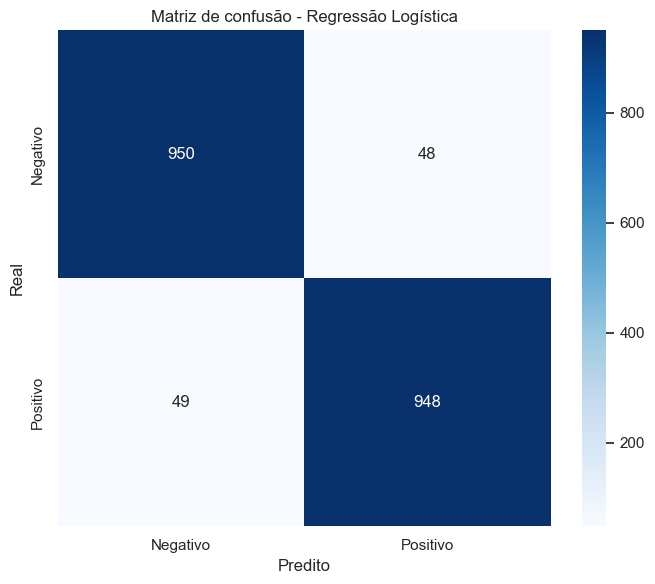

In [14]:
# Relatório de classificação para o melhor modelo TF-IDF no conjunto de teste
print(f'Relatório de classificação - {nome_melhor_tfidf}')
print(classification_report(y_teste, pred_teste_tfidf, labels=ROTULOS_ORDENADOS, target_names=NOMES_CLASSES, zero_division=0))

# Matriz de confusão para o melhor modelo TF-IDF no conjunto de teste
matriz_tfidf = confusion_matrix(y_teste, pred_teste_tfidf, labels=ROTULOS_ORDENADOS)
plt.figure(figsize=(7, 6))
sns.heatmap(matriz_tfidf, annot=True, fmt='d', cmap='Blues', xticklabels=NOMES_CLASSES, yticklabels=NOMES_CLASSES)
plt.title(f'Matriz de confusão - {nome_melhor_tfidf}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

- 950 negativos foram classificados corretamente.
- 948 positivos foram classificados corretamente.
- 48 Falsos positivos.
- 49 Falsos negativos.
- Os acertos ficaram próximos nas duas classes, indicando equilíbrio.
- O número de erros foi baixo, sugerindo bom desempenho geral.
- Acurácia e F1-Score próximo de 0.95

# **Etapa 2** — Fine-Tuning com BERTimbau

Nessa etapa, é utilizado o BERTimbau como modelo pré ajustado. Nesse processo, os parâmetros do modelo são refinados para melhorar seu desempenho na classificação das avaliações do nosso contexto. Para o Transformer, é utilizado a mesma divisão criada anteriormente para preserv a comparabilidade metodológica entre os modelos.


In [15]:
# Define o modelo BERT e o tokenizador para português
modelo_bert_nome = 'neuralmind/bert-base-portuguese-cased'
tokenizador = AutoTokenizer.from_pretrained(modelo_bert_nome)
ROTULOS_ORDENADOS = sorted(pd.Series(y_treino).unique().tolist())

print('Modelo BERT usado:', modelo_bert_nome)

Modelo BERT usado: neuralmind/bert-base-portuguese-cased


## Etapa 2.1 — Construção do dataset PyTorch

A classe abaixo encapsula a tokenização e devolve exemplos no formato esperado pela biblioteca Transformers via PyTorch. O truncamento é configurado para 128 tokens, valor compatível com avaliações curtas e médias de e-commerce.

In [16]:
 # Tokenizador automático para o modelo português
modelo_bert_nome = 'neuralmind/bert-base-portuguese-cased'
tokenizador = AutoTokenizer.from_pretrained(modelo_bert_nome)

 # Garante que os rótulos usados no BERT sejam exatamente os mesmos do TF-IDF
ROTULOS_ORDENADOS = sorted(pd.Series(y_treino).unique().tolist())

print('Modelo BERT usado:', modelo_bert_nome)
print('Validação e teste do BERT usarão exatamente os conjuntos oficiais do notebook.')

TAMANHO_MAXIMO_BERT = 128 # Limite de tokens

# Usa o mesmo split do TF-IDF
X_treino_bert_final = list(X_treino_bert)
y_treino_bert_final = list(y_treino)
ids_treino_bert_final = list(ids_treino)

X_valid_bert_final = list(X_valid_bert)
y_valid_bert_final = list(y_valid)
ids_valid_bert_final = list(ids_valid)

X_teste_bert_final = list(X_teste_bert)
y_teste_bert_final = list(y_teste)
ids_teste_bert_final = list(ids_teste)

# Verificações de integridade dos splits para o BERT
assert len(X_treino_bert_final) == len(X_treino_tfidf)
assert len(X_valid_bert_final) == len(X_valid_bert)
assert len(X_teste_bert_final) == len(X_teste_bert)
assert ids_treino_bert_final == list(ids_treino)
assert ids_teste_bert_final == list(ids_teste)

# Resumo dos splits para o BERT
print('Tamanhos usados no BERTimbau (idênticos ao TF-IDF):')
print(f'Treino:    {len(X_treino_bert_final)}')
print(f'Validação: {len(X_valid_bert_final)}')
print(f'Teste:     {len(X_teste_bert_final)}')
print('Distribuição treino BERT:', pd.Series(y_treino_bert_final).value_counts().sort_index().to_dict())
print('Distribuição validação BERT:', pd.Series(y_valid_bert_final).value_counts().sort_index().to_dict())
print('Distribuição teste BERT:', pd.Series(y_teste_bert_final).value_counts().sort_index().to_dict())


Modelo BERT usado: neuralmind/bert-base-portuguese-cased
Validação e teste do BERT usarão exatamente os conjuntos oficiais do notebook.
Tamanhos usados no BERTimbau (idênticos ao TF-IDF):
Treino:    15956
Validação: 1995
Teste:     1995
Distribuição treino BERT: {0: 7978, 1: 7978}
Distribuição validação BERT: {0: 997, 1: 998}
Distribuição teste BERT: {0: 998, 1: 997}


In [17]:
# Dataset personalizado para o BERT
class DatasetAvaliacoes(torch.utils.data.Dataset):

    # Inicializa o dataset com os textos, rótulos, tokenizador e tamanho máximo
    def __init__(self, textos, rotulos, tokenizer, max_length=128):
        self.textos = list(textos)
        self.rotulos = list(rotulos)
        self.tokenizer = tokenizer
        self.max_length = max_length

    # Retorna o número de amostras no dataset
    def __len__(self):
        return len(self.textos)

    # Retorna um item do dataset tokenizado e com o rótulo
    def __getitem__(self, idx):
        texto = str(self.textos[idx])
        rotulo = int(self.rotulos[idx])

        encoding = self.tokenizer(
            texto,
            truncation=True,
            padding=False,
            max_length=self.max_length,
        )
        encoding["labels"] = rotulo
        return {k: torch.tensor(v) for k, v in encoding.items()}

In [18]:
# Cria os datasets para treino, validação e teste do BERT
conjunto_treino = DatasetAvaliacoes(X_treino_bert_final, y_treino_bert_final, tokenizador)
conjunto_valid = DatasetAvaliacoes(X_valid_bert_final, y_valid_bert_final, tokenizador)
conjunto_teste = DatasetAvaliacoes(X_teste_bert_final, y_teste_bert_final, tokenizador)

# Colisor para garantir que os lotes sejam corretamente preenchidos
colisor = DataCollatorWithPadding(tokenizer=tokenizador)

# Pesos de classe são ignorados, pois já estão balanceados
pesos_tensores = None


## Etapa 2.2 — Modelo do BERT e função de perda

Como o treino do BERT nesta versão já está balanceado por subamostragem estratificada, a perda ponderada só é ativada se houver desbalanceamento residual. Isso evita complexidade desnecessária e elimina a inconsistência de usar pesos unitários sem efeito prático.


In [19]:
# Treinamento do BERTimbau usando o Trainer personalizado para lidar com pesos de classe (se necessário)
class TrainerPonderado(Trainer):
    def __init__(self, *args, pesos_classe=None, **kwargs):
        self.pesos_classe = pesos_classe
        kwargs.pop('tokenizer', None)
        kwargs.pop('processing_class', None)
        super().__init__(*args, **kwargs)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        rotulos = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits

        # Caso haja pesos de classe, utiliza-os na função de perda; caso contrário, usa a perda padrão
        if self.pesos_classe is not None:
            pesos = self.pesos_classe.to(logits.device)
            funcao_perda = torch.nn.CrossEntropyLoss(weight=pesos)
        else:
            funcao_perda = torch.nn.CrossEntropyLoss()

        perda = funcao_perda(logits, rotulos)
        return (perda, outputs) if return_outputs else perda


In [20]:
# Função para calcular as métricas de avaliação do BERT
def funcao_metricas(avaliacao):
    logits, rotulos = avaliacao
    predicoes = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(rotulos, predicoes),
        'precision_macro': precision_score(rotulos, predicoes, average='macro', zero_division=0, labels=ROTULOS_ORDENADOS),
        'recall_macro': recall_score(rotulos, predicoes, average='macro', zero_division=0, labels=ROTULOS_ORDENADOS),
        'f1_macro': f1_score(rotulos, predicoes, average='macro', zero_division=0, labels=ROTULOS_ORDENADOS)
    }

In [21]:
# Carrega o modelo BERTimbau para classificação de sequência
modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    modelo_bert_nome,
    num_labels=len(ROTULOS_ORDENADOS)
)

# Configura os argumentos de treinamento para o BERTimbau
argumentos_treinamento = TrainingArguments(
    output_dir='saida_bertimbau',
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    seed=SEMENTE
)

# Cria o Trainer personalizado para o BERTimbau, passando os pesos de classe e as métricas de avaliação
trainer = Trainer(
    model=modelo_bert,
    args=argumentos_treinamento,
    train_dataset=conjunto_treino,
    eval_dataset=conjunto_valid,
    data_collator=colisor,
    compute_metrics=funcao_metricas,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

## Etapa 2.3 — Treinamento do BERTimbau

Nessa etapa é executado o treinamento e avaliação do modelo BERT.

In [22]:
# Inicia o treinamento do BERTimbau e avalia no conjunto de validação
resultado_treinamento = trainer.train()
resultado_validacao = trainer.evaluate(conjunto_valid)
resultado_validacao

c:\Users\Usuario\Desktop\Análise de Sentimento\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.200461,0.166986,0.957393,0.957394,0.957393,0.957393


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Usuario\Desktop\Análise de Sentimento\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.200461,0.166986,1,0.957393,0.957394,0.957393,0.957393


{'eval_loss': 0.16698552668094635,
 'eval_accuracy': 0.9573934837092731,
 'eval_precision_macro': 0.9573941411290809,
 'eval_recall_macro': 0.9573932217494165,
 'eval_f1_macro': 0.9573934408888798}

In [23]:
# Avaliação do modelo no conjunto de teste
resultado_teste = trainer.predict(conjunto_teste)
pred_teste_bert = np.argmax(resultado_teste.predictions, axis=1)
y_teste_bert_series = pd.Series(y_teste_bert_final)

# Verificações de integridade do teste
assert len(pred_teste_bert) == len(y_teste_bert_series) == len(y_teste)
assert list(ids_teste_bert_final) == list(ids_teste)

metricas_bert_teste = pd.DataFrame([
    calcular_metricas(y_teste_bert_series, pred_teste_bert, 'BERTimbau')
])
metricas_bert_teste


c:\Users\Usuario\Desktop\Análise de Sentimento\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,modelo,acuracia,precision_macro,recall_macro,f1_macro
0,BERTimbau,0.964912,0.964957,0.964915,0.964912


Relatório de classificação — BERTimbau
              precision    recall  f1-score   support

    Negativo       0.97      0.96      0.96       998
    Positivo       0.96      0.97      0.97       997

    accuracy                           0.96      1995
   macro avg       0.96      0.96      0.96      1995
weighted avg       0.96      0.96      0.96      1995



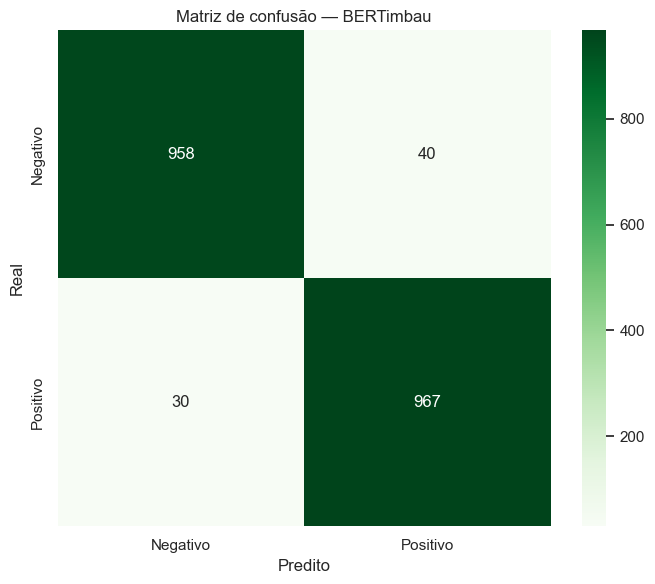

In [24]:
# Relatório de classificação para o modelo BERTimbau no conjunto de teste
print('Relatório de classificação — BERTimbau')
print(classification_report(y_teste_bert_final, pred_teste_bert, labels=ROTULOS_ORDENADOS, target_names=NOMES_CLASSES, zero_division=0))

matriz_bert = confusion_matrix(y_teste_bert_final, pred_teste_bert, labels=ROTULOS_ORDENADOS)
plt.figure(figsize=(7, 6))
sns.heatmap(matriz_bert, annot=True, fmt='d', cmap='Greens', xticklabels=NOMES_CLASSES, yticklabels=NOMES_CLASSES)
plt.title('Matriz de confusão — BERTimbau')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


- 958 avaliações negativas foram classificadas corretamente.
- 967 avaliações positivas foram classificadas corretamente.
- 40 Falsos positivos.
- 30 Falsos negativos.
- O modelo apresenta alto desempenho geral, com maioria expressiva de acertos.
- Há poucos erros nas duas classes, indicando boa consistência.
- O número de erros é menor para positivos do que para negativos.
- A matriz sugere boa capacidade de generalização do BERTimbau.
- Acurácia e F1-Score próximo de 0.97

# **Etapa 3** — Comparação quantitativa entre as abordagens

Como feito em todas as outras etapas, a comparação abaixo é feita exclusivamente no mesmo conjunto. Isso garante alinhamento e elimina a incoerência de comparar modelos avaliados em subconjuntos diferentes.


In [25]:
# Verificações finais de integridade antes da comparação e construção da tabela comparativa
assert len(pred_teste_tfidf) == len(pred_teste_bert) == len(y_teste)
assert list(ids_teste) == list(ids_teste_bert_final)

tabela_comparativa = pd.concat([metricas_tfidf_teste, metricas_bert_teste], ignore_index=True)
tabela_comparativa['tamanho_teste'] = len(y_teste)
tabela_comparativa = tabela_comparativa.sort_values('f1_macro', ascending=False).reset_index(drop=True)
tabela_comparativa

,modelo,acuracia,precision_macro,recall_macro,f1_macro,tamanho_teste
0,BERTimbau,0.964912,0.964957,0.964915,0.964912,1995
1,Regressão Logística,0.951378,0.951379,0.951378,0.951378,1995


- BERTimbau supera a Regressão Logística em todas as métricas, porém por apenas ~1,42%.
- Ambos os modelos apresentam desempenho elevado, com acurácia acima de 95%.
- A Regressão Logística, mesmo sendo um modelo mais simples, obteve resultados muito próximos aos do BERT.

- **A margem de vantagem do BERT é pequena, o que sugere que o TF-IDF + Regressão Logística é uma alternativa competitiva para essa tarefa.**

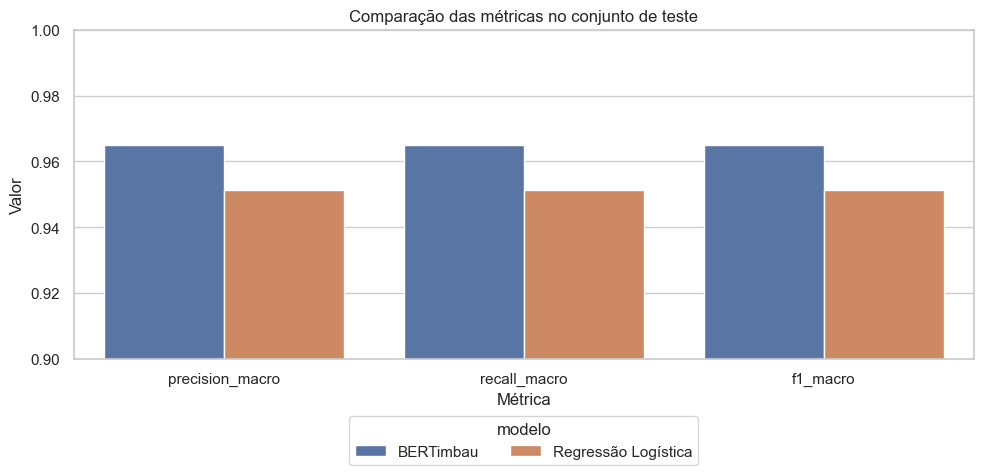

In [33]:
# Visualização comparativa das métricas dos modelos no conjunto de teste
metricas_plot = tabela_comparativa.melt(id_vars='modelo', value_vars=['precision_macro', 'recall_macro', 'f1_macro'], var_name='metrica', value_name='valor')

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=metricas_plot, x='metrica', y='valor', hue='modelo')
plt.ylim(0.9, 1)
plt.title('Comparação das métricas no conjunto de teste')
plt.ylabel('Valor')
plt.xlabel('Métrica')

plt.legend(
    title='modelo',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout()
plt.show()

## Etapa 3.1 — Análise de erros e e exemplos de divergências

A célula abaixo monta automaticamente uma tabela com casos divergentes, preservando o texto original para inspeção manual.

A partir dessa tabela, é possíel observar casos de:
- ironia;
- negação complexa;
- ambiguidade lexical;
- mistura de elogio e crítica na mesma frase;
- avaliações muito curtas ou pouco informativas.

Essas características são pontos chaves que podem servir de exemplos do por que houve divergência entre ambos modelos.

In [27]:
# Análise dos casos em que os modelos divergiram, destacando os erros específicos de cada modelo
analise_erros = pd.DataFrame({
    'id_unico': list(ids_teste),
    'texto_bruto': list(X_teste_bert),
    'rating': list(ratings_teste),
    'y_real': list(y_teste),
    'pred_tfidf': list(pred_teste_tfidf),
    'pred_bert': list(pred_teste_bert)
})

analise_erros['classe_real'] = analise_erros['y_real'].map(mapa_rotulos)
analise_erros['classe_pred_tfidf'] = analise_erros['pred_tfidf'].map(mapa_rotulos)
analise_erros['classe_pred_bert'] = analise_erros['pred_bert'].map(mapa_rotulos)
analise_erros['acerto_tfidf'] = analise_erros['y_real'] == analise_erros['pred_tfidf']
analise_erros['acerto_bert'] = analise_erros['y_real'] == analise_erros['pred_bert']
analise_erros['divergentes'] = analise_erros['pred_tfidf'] != analise_erros['pred_bert']
analise_erros['tfidf_erra_bert_acerta'] = (~analise_erros['acerto_tfidf']) & (analise_erros['acerto_bert'])
analise_erros['bert_erra_tfidf_acerta'] = (~analise_erros['acerto_bert']) & (analise_erros['acerto_tfidf'])

print('Casos em que TF-IDF erra e BERT acerta:', int(analise_erros['tfidf_erra_bert_acerta'].sum()))
print('Casos em que BERT erra e TF-IDF acerta:', int(analise_erros['bert_erra_tfidf_acerta'].sum()))
print('Casos divergentes totais:', int(analise_erros['divergentes'].sum()))

exemplos_tfidf_erra = analise_erros.loc[
    analise_erros['tfidf_erra_bert_acerta'],
    ['id_unico', 'rating', 'texto_bruto', 'classe_real', 'classe_pred_tfidf', 'classe_pred_bert']
].head(3)

exemplos_bert_erra = analise_erros.loc[
    analise_erros['bert_erra_tfidf_acerta'],
    ['id_unico', 'rating', 'texto_bruto', 'classe_real', 'classe_pred_tfidf', 'classe_pred_bert']
].head(3)

print('Exemplos em que o TF-IDF erra e o BERT acerta:')
display(exemplos_tfidf_erra)

print('Exemplos em que o BERT erra e o TF-IDF acerta:')
display(exemplos_bert_erra)

Casos em que TF-IDF erra e BERT acerta: 53
Casos em que BERT erra e TF-IDF acerta: 26
Casos divergentes totais: 79
Exemplos em que o TF-IDF erra e o BERT acerta:


,id_unico,rating,texto_bruto,classe_real,classe_pred_tfidf,classe_pred_bert
19,reviews_mercadolivre_com_br_2.json::54762,5,Alisa 100%.,positivo,negativo,positivo
45,reviews_mercadolivre_com_br_1.json::30128,5,"Muito, não é pegajoso e não sai fácil na água.",positivo,negativo,positivo
143,reviews_mercadolivre_com_br_1.json::95778,1,Não tenho muito o que falar sobre o produto não usei ainda mas o cheiro é bem forte.,negativo,positivo,negativo


Exemplos em que o BERT erra e o TF-IDF acerta:


,id_unico,rating,texto_bruto,classe_real,classe_pred_tfidf,classe_pred_bert
16,reviews_mercadolivre_com_br_1.json::87857,2,Pro.,negativo,negativo,positivo
17,reviews_mercadolivre_com_br_1.json::88618,1,Normal.,negativo,negativo,positivo
22,reviews_mercadolivre_com_br_2.json::80373,2,"Comecei a tomar ontem , então não tem como eu avaliar ainda 😃 daqui há algumas semanas com fé em deus eu observo o resultado 🙏.",negativo,negativo,positivo


**Levantamento de hipóteses:**

Nessa etapa, é plausível levantarmos possíveis motivos no qual podem explicar como cada modelo errou.

**Exemplos de possíveis motivos do TF-IDF + Regressão ter errado:**

- `"Alisa 100%."`: Texto curto e ambíguo, difícil de capturar o sentido.

- `"Muito, não é pegajoso e não sai fácil na água."`: Há  uma negação e estrutura semântica incomum.

- `“Não tenho muito o que falar sobre o produto não usei ainda mas o cheiro é bem forte."`: texto com negação, hesitação e crítica indireta.

**Exemplos de possíveis motivos o BERTimbau ter errado:**

- `"Pro."`: Token curto e fácil de ser associado à algo positivo.

- `"Normal"`: Palavra vaga e próximo de padrões de ratings neutros.

- `"Comecei a tomar ontem, então não tem como eu avaliar ainda. Daqui há algumas semanas com fé em Deus eu observo o resultado."`: Inconclusivo e esperançoso, pouca quantidade de informação.

## Etapa 3.2 — Comparação dos niveis de confiança com boostrap e reposição

A análise do nível de confiança é importante para verificar a estabilidade dos resultados obtidos pelos modelos e reduzir o risco de conclusões baseadas em uma única amostra. Ao comparar TF-IDF e BERT por meio de bootstrap, é possível avaliar não apenas qual modelo apresenta melhor desempenho, mas também se essa diferença é consistente. Dessa forma, a interpretação fica mais robusta e estatisticamente informada.

In [31]:

df_boot = analise_erros.copy()

# Mapeamento de rótulos textuais para 0/1
mapa = {"negativo": 0, "positivo": 1}

y_true = df_boot["classe_real"].map(mapa).to_numpy()
y_pred_tfidf = df_boot["classe_pred_tfidf"].map(mapa).to_numpy()
y_pred_bert = df_boot["classe_pred_bert"].map(mapa).to_numpy()

assert len(y_true) == len(y_pred_tfidf) == len(y_pred_bert), "Os vetores precisam ter o mesmo tamanho."

def bootstrap_accuracy(y_true, y_pred, n_boot=5000, seed=SEMENTE): 
    rng = np.random.default_rng(seed)
    n = len(y_true)
    accs = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        accs[i] = np.mean(y_true[idx] == y_pred[idx])

    return accs.mean(), *np.percentile(accs, [2.5, 97.5]), accs

def bootstrap_diff_accuracy(y_true, y_pred_a, y_pred_b, n_boot=5000, seed=SEMENTE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        acc_a = np.mean(y_true[idx] == y_pred_a[idx])
        acc_b = np.mean(y_true[idx] == y_pred_b[idx])
        diffs[i] = acc_b - acc_a

    return diffs.mean(), *np.percentile(diffs, [2.5, 97.5]), np.mean(diffs <= 0), diffs

acc_tfidf, acc_tfidf_inf, acc_tfidf_sup, dist_tfidf = bootstrap_accuracy(
    y_true, y_pred_tfidf, n_boot=5000, seed=SEMENTE
)

acc_bert, acc_bert_inf, acc_bert_sup, dist_bert = bootstrap_accuracy(
    y_true, y_pred_bert, n_boot=5000, seed=SEMENTE
)

diff_media, diff_inf, diff_sup, p_empirico, dist_diff = bootstrap_diff_accuracy(
    y_true, y_pred_tfidf, y_pred_bert, n_boot=5000, seed=SEMENTE
)

resultado_bootstrap = pd.DataFrame({
    "modelo": [
        "TF-IDF + Regressão Logística",
        "BERTimbau",
        "Diferença (BERT - TF-IDF)"
    ],
    "media_bootstrap": [acc_tfidf, acc_bert, diff_media],
    "ic_95_inf": [acc_tfidf_inf, acc_bert_inf, diff_inf],
    "ic_95_sup": [acc_tfidf_sup, acc_bert_sup, diff_sup]
})

display(resultado_bootstrap)

,modelo,media_bootstrap,ic_95_inf,ic_95_sup
0,TF-IDF + Regressão Logística,0.951325,0.941353,0.960902
1,BERTimbau,0.964970,0.956391,0.972932
2,Diferença (BERT - TF-IDF),0.013644,0.004511,0.022556


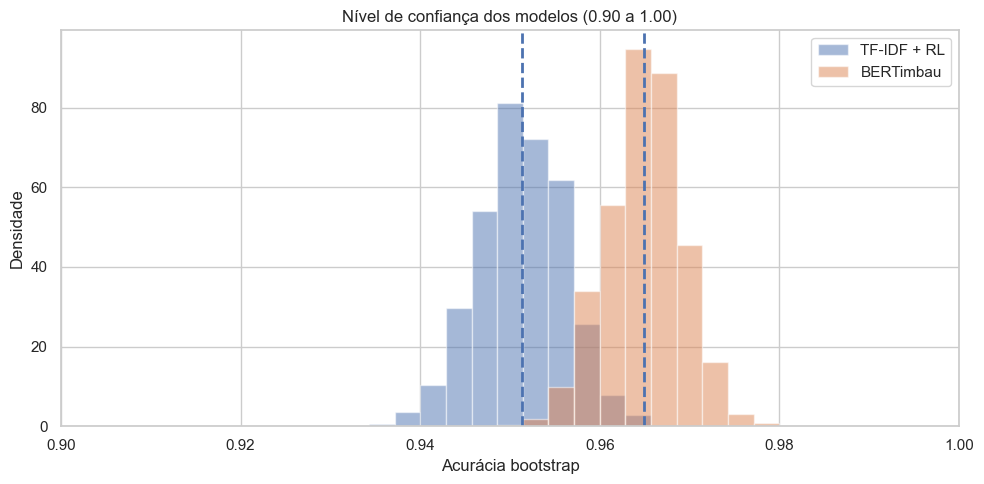

In [32]:
y = analise_erros["y_real"].to_numpy()
t = analise_erros["pred_tfidf"].to_numpy()
b = analise_erros["pred_bert"].to_numpy()

rng = np.random.default_rng(SEMENTE)
boot_t = np.array([np.mean(y[i := rng.integers(0, len(y), len(y))] == t[i]) for _ in range(5000)])
boot_b = np.array([np.mean(y[i := rng.integers(0, len(y), len(y))] == b[i]) for _ in range(5000)])

plt.figure(figsize=(10, 5))
plt.hist(boot_t, bins=35, range=(0.9, 1.0), density=True, alpha=0.5, label="TF-IDF + RL")
plt.hist(boot_b, bins=35, range=(0.9, 1.0), density=True, alpha=0.5, label="BERTimbau")
plt.axvline(boot_t.mean(), ls="--", lw=2)
plt.axvline(boot_b.mean(), ls="--", lw=2)
plt.xlim(0.9, 1.0)
plt.xlabel("Acurácia bootstrap")
plt.ylabel("Densidade")
plt.title("Nível de confiança dos modelos (0.90 a 1.00)")
plt.legend()
plt.tight_layout()
plt.show()

Os resultados de bootstrap indicam vantagem do BERTimbau sobre o TF-IDF + Regressão Logística no teste de 1.995 instâncias, com diferença média de 1,36 pontos porcentis e com intervalo de confiança de 95% inteiramente positivo [0,45% , 2,26%]. Ainda assim, há sobreposição entre as distribuições amostrais, de modo que o TF-IDF pode superar o BERT em algumas reamostragens.

## **Conclusões: TF-IDF** vs **BERT**

- **Resumo geral**

    - O BERTimbau foi melhor no teste final, com desempenho acima do TF-IDF em todas as métricas.
    - Mesmo assim, o TF-IDF ficou muito próximo e continua sendo um baseline forte e útil.
    - Nos casos divergentes, o BERT acertou mais vezes do que errou em relação ao TF-IDF.


- **TF-IDF**

    - Mais simples, rápido e barato de treinar.
    - Bom como baseline e mais fácil de interpretar.
    - Funciona muito bem quando o texto é mais direto.
    - Tem mais dificuldade com contexto, ambiguidade e negação mais complexa.
    - Utilizar quando velocidade e simplicidade é prioridade.


- **BERTimbau**

    - Teve o melhor resultado geral.
    - Captura melhor o contexto e nuances do português.
    - Acertou mais casos difíceis que o TF-IDF.
    - Exige mais processamento e é menos interpretável.
    - Utilizar quando máxima acurácia é prioridade.